# Week 10: Learned Query Pooling with Cross-Attention

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aniJani/reposynth/blob/Research/research/Week10_Learned_Query_Pooler.ipynb)

This notebook demonstrates the learned cross-attention module that replaces the heuristic-based TopicInferrer for CCE-triggered retrieval.

## Overview

**Goal:** Improve retrieval precision beyond the current 0.611 composite score by using learnable query vectors that attend over confused token embeddings.

### Architecture

```
                    ┌─────────────────────────────────────┐
                    │   Learned Query Pooling Module      │
                    └─────────────────────────────────────┘
                                      │
        ┌─────────────────────────────┼─────────────────────────────┐
        ▼                             ▼                             ▼
┌───────────────┐        ┌───────────────────┐        ┌───────────────┐
│ Confused Token│        │  Context Encoder  │        │  Learnable    │
│  Embeddings   │        │ (query + context) │        │ Query Vectors │
│   [K x D]     │        │     [L x D]       │        │   [Q x D]     │
└───────────────┘        └───────────────────┘        └───────────────┘
        │                             │                       │
        └─────────────────────────────┴───────────────────────┘
                                      │
                                      ▼
                    ┌─────────────────────────────────────┐
                    │   Multi-Head Cross-Attention        │
                    │   Q: learnable queries              │
                    │   K/V: confused tokens + context    │
                    └─────────────────────────────────────┘
                                      │
                                      ▼
                    ┌─────────────────────────────────────┐
                    │   Pooling + File Scoring            │
                    │   → retrieval query embedding       │
                    └─────────────────────────────────────┘
```

## 1. Setup & Installation

In [1]:
# Install required packages
!pip install -q sentence-transformers torch numpy matplotlib seaborn pandas

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import re
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Any, Union
from sentence_transformers import SentenceTransformer

# Check if running in Colab
try:
    from google.colab import files
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Running in Google Colab
Using device: cuda


## 2. Define Module Components

All components are defined inline so the notebook is self-contained.

In [3]:
# ============================================================================
# CONFUSED TOKEN ENCODER
# ============================================================================

class ConfusedTokenEncoder(nn.Module):
    """
    Encodes confused tokens from CCE spikes into embeddings.
    Uses SentenceTransformer backbone with optional probability weighting.
    """

    def __init__(
        self,
        embed_dim: int = 384,
        model_name: str = 'all-MiniLM-L6-v2',
        use_probability_weighting: bool = True,
        dropout: float = 0.1,
        max_tokens: int = 20,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.model_name = model_name
        self.use_probability_weighting = use_probability_weighting
        self.max_tokens = max_tokens

        # Load sentence transformer
        self._encoder = SentenceTransformer(model_name)

        # Check actual dimension
        test_emb = self._encoder.encode(["test"])
        actual_dim = test_emb.shape[1]
        self._projection = nn.Linear(actual_dim, embed_dim) if actual_dim != embed_dim else None

        # Probability weighting network
        if use_probability_weighting:
            self.prob_transform = nn.Sequential(
                nn.Linear(1, 16),
                nn.ReLU(),
                nn.Linear(16, 1),
                nn.Sigmoid(),
            )
        else:
            self.prob_transform = None

        self.dropout = nn.Dropout(dropout)
        self.output_norm = nn.LayerNorm(embed_dim)

    def forward(
        self,
        tokens: List[str],
        probabilities: Optional[List[float]] = None,
        return_weights: bool = False,
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        if not tokens:
            empty = torch.zeros(1, self.embed_dim, device=device)
            if return_weights:
                return empty, torch.ones(1, device=device)
            return empty

        tokens = tokens[:self.max_tokens]

        # Encode tokens
        with torch.no_grad():
            raw_embeddings = self._encoder.encode(tokens, convert_to_tensor=True, show_progress_bar=False)

        embeddings = raw_embeddings.to(device)

        if self._projection is not None:
            embeddings = self._projection(embeddings)

        embeddings = self.dropout(embeddings)

        # Compute probability weights
        if self.use_probability_weighting and probabilities is not None:
            probs = probabilities[:len(tokens)]
            prob_tensor = torch.tensor(probs, dtype=torch.float32, device=device).unsqueeze(-1)
            weights = self.prob_transform(prob_tensor).squeeze(-1)
            embeddings = embeddings * weights.unsqueeze(-1)
        else:
            weights = torch.ones(len(tokens), device=device)

        embeddings = self.output_norm(embeddings)

        if return_weights:
            return embeddings, weights
        return embeddings

print("ConfusedTokenEncoder defined")

ConfusedTokenEncoder defined


In [4]:
# ============================================================================
# CONTEXT ENCODER
# ============================================================================

class ContextEncoder(nn.Module):
    """
    Encodes query and generation context into embeddings.
    """

    def __init__(
        self,
        embed_dim: int = 384,
        model_name: str = 'all-MiniLM-L6-v2',
        max_context_length: int = 512,
        chunk_size: int = 128,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.max_context_length = max_context_length
        self.chunk_size = chunk_size

        self._encoder = SentenceTransformer(model_name)

        test_emb = self._encoder.encode(["test"])
        actual_dim = test_emb.shape[1]
        self._projection = nn.Linear(actual_dim, embed_dim) if actual_dim != embed_dim else None

        self.dropout = nn.Dropout(dropout)
        self.type_embeddings = nn.Embedding(2, embed_dim)  # 0=query, 1=context
        self.output_norm = nn.LayerNorm(embed_dim)

    def _chunk_text(self, text: str) -> List[str]:
        text = text[-self.max_context_length:]
        chunks = []
        for i in range(0, len(text), self.chunk_size):
            chunk = text[i:i + self.chunk_size].strip()
            if chunk:
                chunks.append(chunk)
        return chunks if chunks else [""]

    def forward(
        self,
        query: str,
        context: str,
        return_separate: bool = False,
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        texts_to_encode = []
        text_types = []

        if query:
            texts_to_encode.append(query)
            text_types.append(0)

        context_chunks = self._chunk_text(context)
        texts_to_encode.extend(context_chunks)
        text_types.extend([1] * len(context_chunks))

        if not texts_to_encode:
            texts_to_encode = [""]
            text_types = [1]

        with torch.no_grad():
            raw_embeddings = self._encoder.encode(texts_to_encode, convert_to_tensor=True, show_progress_bar=False)

        embeddings = raw_embeddings.to(device)

        if self._projection is not None:
            embeddings = self._projection(embeddings)

        type_tensor = torch.tensor(text_types, dtype=torch.long, device=device)
        type_embs = self.type_embeddings(type_tensor)
        embeddings = embeddings + type_embs

        embeddings = self.dropout(embeddings)
        embeddings = self.output_norm(embeddings)

        if return_separate and query:
            query_emb = embeddings[0:1]
            context_emb = embeddings[1:] if embeddings.shape[0] > 1 else embeddings
            return query_emb, context_emb

        return embeddings

print("ContextEncoder defined")

ContextEncoder defined


In [5]:
# ============================================================================
# LEARNED QUERY POOLER (CORE CROSS-ATTENTION)
# ============================================================================

class LearnedQueryPooler(nn.Module):
    """
    Cross-attention pooler with learnable query vectors.
    Uses learnable queries to attend over confused tokens and context.
    """

    def __init__(
        self,
        embed_dim: int = 384,
        num_query_vectors: int = 4,
        num_heads: int = 4,
        dropout: float = 0.1,
        fusion_method: str = "concat",
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_query_vectors = num_query_vectors
        self.fusion_method = fusion_method

        # Learnable query vectors
        self.query_vectors = nn.Parameter(torch.randn(num_query_vectors, embed_dim) * 0.02)

        # Cross-attention layers
        self.token_cross_attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.context_cross_attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)

        # Fusion
        if fusion_method == "concat":
            self.fusion = nn.Sequential(nn.Linear(embed_dim * 2, embed_dim), nn.GELU(), nn.Dropout(dropout))
        elif fusion_method == "gated":
            self.gate = nn.Sequential(nn.Linear(embed_dim * 2, embed_dim), nn.Sigmoid())
            self.fusion = None
        else:
            self.fusion = None

        self.output_projection = nn.Linear(embed_dim, embed_dim)
        self.token_norm = nn.LayerNorm(embed_dim)
        self.context_norm = nn.LayerNorm(embed_dim)
        self.output_norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

        self._last_token_attn = None
        self._last_context_attn = None

    def forward(
        self,
        confused_token_embs: torch.Tensor,
        context_embs: torch.Tensor,
        return_attention_weights: bool = False,
    ) -> Tuple[torch.Tensor, Optional[Dict[str, torch.Tensor]]]:
        if confused_token_embs.dim() == 2:
            confused_token_embs = confused_token_embs.unsqueeze(0)
        if context_embs.dim() == 2:
            context_embs = context_embs.unsqueeze(0)

        batch_size = confused_token_embs.shape[0]
        queries = self.query_vectors.unsqueeze(0).expand(batch_size, -1, -1)

        # Cross-attend to tokens
        token_attended, token_attn = self.token_cross_attn(queries, confused_token_embs, confused_token_embs)
        token_attended = self.token_norm(token_attended)

        # Cross-attend to context
        context_attended, context_attn = self.context_cross_attn(queries, context_embs, context_embs)
        context_attended = self.context_norm(context_attended)

        self._last_token_attn = token_attn.detach()
        self._last_context_attn = context_attn.detach()

        # Fuse
        if self.fusion_method == "concat":
            fused = torch.cat([token_attended, context_attended], dim=-1)
            fused = self.fusion(fused)
        elif self.fusion_method == "gated":
            gate_input = torch.cat([token_attended, context_attended], dim=-1)
            gate = self.gate(gate_input)
            fused = gate * token_attended + (1 - gate) * context_attended
        else:
            fused = token_attended + context_attended

        pooled = fused.mean(dim=1)
        output = self.output_projection(pooled)
        output = self.dropout(output)
        output = self.output_norm(output)

        if batch_size == 1:
            output = output.squeeze(0)

        attention_weights = None
        if return_attention_weights:
            attention_weights = {'token_attention': token_attn, 'context_attention': context_attn}

        return output, attention_weights

    def get_attention_weights(self):
        return {'token_attention': self._last_token_attn, 'context_attention': self._last_context_attn}

print("LearnedQueryPooler defined")

LearnedQueryPooler defined


In [6]:
# ============================================================================
# FILE SCORER
# ============================================================================

class LearnedFileScorer(nn.Module):
    """Scores files using learned embeddings."""

    def __init__(self, embed_dim: int = 384, scoring_method: str = "bilinear", dropout: float = 0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.scoring_method = scoring_method

        if scoring_method == "bilinear":
            self.bilinear = nn.Bilinear(embed_dim, embed_dim, 1, bias=True)
        elif scoring_method == "mlp":
            self.mlp = nn.Sequential(
                nn.Linear(embed_dim * 2, 256), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(128, 1),
            )

        self.query_projection = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query_emb: torch.Tensor, file_embs: torch.Tensor, return_probabilities: bool = False):
        query_batch = query_emb.dim() >= 2
        file_batch = file_embs.dim() >= 3

        if not query_batch:
            query_emb = query_emb.unsqueeze(0)
        if not file_batch:
            file_embs = file_embs.unsqueeze(0)

        batch_size = query_emb.shape[0]
        num_files = file_embs.shape[1]

        query_emb = self.query_projection(query_emb)
        query_emb = self.dropout(query_emb)

        if self.scoring_method == "cosine":
            query_norm = F.normalize(query_emb, p=2, dim=-1)
            file_norm = F.normalize(file_embs, p=2, dim=-1)
            scores = torch.bmm(query_norm.unsqueeze(1), file_norm.transpose(1, 2)).squeeze(1)
        elif self.scoring_method == "bilinear":
            query_expanded = query_emb.unsqueeze(1).expand(-1, num_files, -1)
            query_flat = query_expanded.reshape(-1, self.embed_dim)
            file_flat = file_embs.reshape(-1, self.embed_dim)
            scores = self.bilinear(query_flat, file_flat).reshape(batch_size, num_files)
        else:  # mlp
            query_expanded = query_emb.unsqueeze(1).expand(-1, num_files, -1)
            combined = torch.cat([query_expanded, file_embs], dim=-1)
            scores = self.mlp(combined.reshape(-1, self.embed_dim * 2)).reshape(batch_size, num_files)

        if not query_batch:
            scores = scores.squeeze(0)

        if return_probabilities:
            probs = F.softmax(scores, dim=-1)
            return scores, probs
        return scores

print("LearnedFileScorer defined")

LearnedFileScorer defined


In [7]:
# ============================================================================
# FILE EMBEDDING CACHE
# ============================================================================

class FileEmbeddingCache:
    """Cache for file embeddings."""

    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        self._encoder = SentenceTransformer(model_name)
        self._cache = {}
        self._embeddings_tensor = None
        self._file_paths = []

    def _path_to_text(self, path: str) -> str:
        parts = re.split(r'[/\\]', path)
        words = []
        for part in parts:
            name = re.sub(r'\.[^.]+$', '', part)
            for subpart in name.split('_'):
                if len(subpart) >= 2:
                    words.append(subpart.lower())
            camel_parts = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', name)
            for cp in camel_parts:
                if len(cp) >= 2 and cp.lower() not in words:
                    words.append(cp.lower())
        return ' '.join(words)

    def build_cache(self, file_paths: List[str]) -> torch.Tensor:
        self._file_paths = file_paths
        texts = [self._path_to_text(path) for path in file_paths]
        embeddings = self._encoder.encode(texts, show_progress_bar=False)
        for i, path in enumerate(file_paths):
            self._cache[path] = embeddings[i]
        self._embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32, device=device)
        return self._embeddings_tensor

    def get_embeddings(self):
        return self._embeddings_tensor

    def get_file_paths(self):
        return self._file_paths.copy()

print("FileEmbeddingCache defined")

FileEmbeddingCache defined


In [8]:
# ============================================================================
# LEARNED QUERY MODULE (MAIN CLASS)
# ============================================================================

@dataclass
class LearnedQueryResult:
    """Result from the learned query module."""
    query_embedding: torch.Tensor
    matched_files: List[str]
    file_scores: Dict[str, float]
    confidence: float
    token_attention: Optional[torch.Tensor] = None
    context_attention: Optional[torch.Tensor] = None
    confused_tokens: Optional[List[str]] = None
    token_weights: Optional[torch.Tensor] = None


class LearnedQueryModule(nn.Module):
    """Main module combining all learned query components."""

    def __init__(
        self,
        embed_dim: int = 384,
        num_query_vectors: int = 4,
        num_heads: int = 4,
        dropout: float = 0.1,
        model_name: str = 'all-MiniLM-L6-v2',
        scoring_method: str = "bilinear",
        score_threshold: float = 0.3,
        top_k: int = 3,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.score_threshold = score_threshold
        self.top_k = top_k

        self.token_encoder = ConfusedTokenEncoder(embed_dim=embed_dim, model_name=model_name, dropout=dropout)
        self.context_encoder = ContextEncoder(embed_dim=embed_dim, model_name=model_name, dropout=dropout)
        self.pooler = LearnedQueryPooler(embed_dim=embed_dim, num_query_vectors=num_query_vectors, num_heads=num_heads, dropout=dropout)
        self.scorer = LearnedFileScorer(embed_dim=embed_dim, scoring_method=scoring_method, dropout=dropout)
        self.file_cache = FileEmbeddingCache(model_name=model_name)
        self._file_paths = []
        self._file_embeddings = None

    def set_available_files(self, file_paths: List[str]):
        self._file_paths = file_paths
        self._file_embeddings = self.file_cache.build_cache(file_paths)

    def forward(
        self,
        confused_tokens: List[str],
        confused_probs: Optional[List[float]] = None,
        original_query: str = "",
        generated_context: str = "",
        return_attention: bool = False,
    ) -> LearnedQueryResult:
        if not confused_tokens:
            return LearnedQueryResult(
                query_embedding=torch.zeros(self.embed_dim, device=device),
                matched_files=[], file_scores={}, confidence=0.0,
            )

        token_embs, token_weights = self.token_encoder(confused_tokens, confused_probs, return_weights=True)
        context_embs = self.context_encoder(original_query, generated_context)
        query_emb, attention_weights = self.pooler(token_embs, context_embs, return_attention_weights=True)

        matched_files, file_scores = [], {}
        if self._file_embeddings is not None:
            scores, probs = self.scorer(query_emb, self._file_embeddings, return_probabilities=True)
            scores_np = probs.detach().cpu().numpy()
            for i, path in enumerate(self._file_paths):
                file_scores[path] = float(scores_np[i])
            sorted_files = sorted(file_scores.items(), key=lambda x: -x[1])
            matched_files = [f for f, s in sorted_files[:self.top_k] if s >= self.score_threshold]

        # Compute confidence from attention entropy (clamped to [0, 1])
        confidence = 0.5
        if attention_weights:
            token_attn = attention_weights.get('token_attention')
            if token_attn is not None:
                with torch.no_grad():
                    attn = token_attn.mean(dim=(0, 1)).clamp(min=1e-8)
                    entropy = -(attn * torch.log(attn)).sum()
                    max_entropy = np.log(len(attn)) if len(attn) > 1 else 1.0
                    if max_entropy > 0:
                        raw_conf = 1.0 - (entropy.item() / max_entropy)
                        confidence = float(max(0.0, min(1.0, raw_conf)))  # Clamp to [0, 1]
                    else:
                        confidence = 0.5

        result = LearnedQueryResult(
            query_embedding=query_emb,
            matched_files=matched_files,
            file_scores=file_scores,
            confidence=confidence,
            confused_tokens=confused_tokens,
            token_weights=token_weights,
        )
        if return_attention and attention_weights:
            result.token_attention = attention_weights.get('token_attention')
            result.context_attention = attention_weights.get('context_attention')
        return result

print("LearnedQueryModule defined")

LearnedQueryModule defined


In [9]:
# ============================================================================
# LOSS FUNCTION
# ============================================================================

class QueryPoolerLoss(nn.Module):
    """Combined loss for training: ranking + contrastive + attention regularization."""

    def __init__(
        self,
        ranking_margin: float = 0.5,
        ranking_weight: float = 1.0,
        contrastive_weight: float = 0.5,
        attention_reg_weight: float = 0.1,
        temperature: float = 0.07,
    ):
        super().__init__()
        self.ranking_margin = ranking_margin
        self.ranking_weight = ranking_weight
        self.contrastive_weight = contrastive_weight
        self.attention_reg_weight = attention_reg_weight
        self.temperature = temperature

    def forward(
        self,
        query_emb: torch.Tensor,
        file_embs: torch.Tensor,
        file_scores: torch.Tensor,
        relevant_indices: List[int],
        attention_weights: Optional[Dict[str, torch.Tensor]] = None,
    ):
        if query_emb.dim() == 1:
            query_emb = query_emb.unsqueeze(0)
        if file_embs.dim() == 2:
            file_embs = file_embs.unsqueeze(0)
        if file_scores.dim() == 1:
            file_scores = file_scores.unsqueeze(0)

        batch_size, num_files = file_scores.shape[0], file_scores.shape[1]

        # Build relevance mask
        relevance_mask = torch.zeros(batch_size, num_files, device=query_emb.device)
        for idx in relevant_indices:
            if idx < num_files:
                relevance_mask[:, idx] = 1.0

        # Ranking loss
        pos_mask = relevance_mask.bool()
        neg_mask = ~pos_mask
        ranking_loss = torch.tensor(0.0, device=query_emb.device)
        if pos_mask.any() and neg_mask.any():
            for b in range(batch_size):
                pos_scores = file_scores[b, pos_mask[b]]
                neg_scores = file_scores[b, neg_mask[b]]
                if len(pos_scores) > 0 and len(neg_scores) > 0:
                    for ps in pos_scores:
                        margins = self.ranking_margin + neg_scores - ps
                        ranking_loss = ranking_loss + F.relu(margins).mean()

        # Contrastive loss (InfoNCE)
        query_norm = F.normalize(query_emb, p=2, dim=-1)
        file_norm = F.normalize(file_embs, p=2, dim=-1)
        similarities = torch.bmm(query_norm.unsqueeze(1), file_norm.transpose(1, 2)).squeeze(1)
        logits = similarities / self.temperature
        pos_logits = logits.clone()
        pos_logits[~pos_mask] = float('-inf')
        contrastive_loss = -(torch.logsumexp(pos_logits, dim=-1) - torch.logsumexp(logits, dim=-1)).mean() if pos_mask.any() else torch.tensor(0.0, device=query_emb.device)

        # Attention regularization
        attention_loss = torch.tensor(0.0, device=query_emb.device)
        if attention_weights and self.attention_reg_weight > 0:
            for attn in attention_weights.values():
                if attn is not None:
                    if attn.dim() == 2:
                        attn = attn.unsqueeze(0)
                    attn_clamped = attn.clamp(min=1e-8)
                    entropy = -(attn_clamped * torch.log(attn_clamped)).sum(dim=-1)
                    attention_loss = attention_loss + entropy.mean()

        total_loss = self.ranking_weight * ranking_loss + self.contrastive_weight * contrastive_loss + self.attention_reg_weight * attention_loss

        return total_loss, {
            'total': total_loss.item(),
            'ranking': ranking_loss.item(),
            'contrastive': contrastive_loss.item(),
            'attention_reg': attention_loss.item(),
        }

print("QueryPoolerLoss defined")

QueryPoolerLoss defined


## 3. Demo: Confused Token Encoding

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Token embeddings shape: torch.Size([6, 384])
Probability weights: ['0.505', '0.506', '0.507', '0.508', '0.508', '0.509']


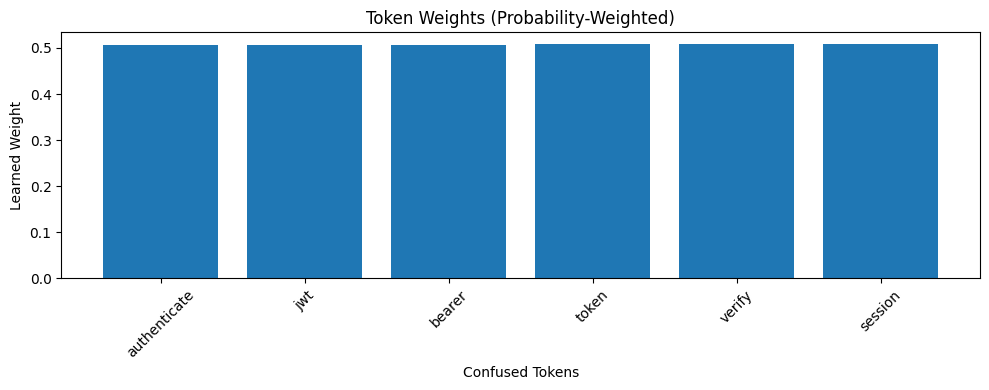

In [10]:
# Initialize encoder
token_encoder = ConfusedTokenEncoder(embed_dim=384).to(device)

# Sample confused tokens from a CCE spike
confused_tokens = ["authenticate", "jwt", "bearer", "token", "verify", "session"]
confused_probs = [0.25, 0.20, 0.15, 0.12, 0.10, 0.08]

# Encode with probability weighting
embeddings, weights = token_encoder(confused_tokens, confused_probs, return_weights=True)

print(f"Token embeddings shape: {embeddings.shape}")
print(f"Probability weights: {[f'{w:.3f}' for w in weights.tolist()]}")

# Visualize token contributions
plt.figure(figsize=(10, 4))
plt.bar(confused_tokens, weights.detach().cpu().numpy())
plt.xlabel('Confused Tokens')
plt.ylabel('Learned Weight')
plt.title('Token Weights (Probability-Weighted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Demo: Context Encoding

In [11]:
# Initialize context encoder
context_encoder = ContextEncoder(embed_dim=384).to(device)

# Sample context
original_query = "How does authentication work in the Flask app?"
generated_context = """In our Flask application, authentication is handled by a custom module.
The system uses JWT tokens for stateless authentication.
When a user logs in, the server verifies their credentials and"""

# Encode
query_emb, context_emb = context_encoder(original_query, generated_context, return_separate=True)

print(f"Query embedding shape: {query_emb.shape}")
print(f"Context embeddings shape: {context_emb.shape}")

Query embedding shape: torch.Size([1, 384])
Context embeddings shape: torch.Size([2, 384])


## 5. Demo: Learned Query Pooler with Cross-Attention

In [12]:
# Initialize pooler with full configuration (accuracy priority)
pooler = LearnedQueryPooler(
    embed_dim=384,
    num_query_vectors=4,
    num_heads=4,
    dropout=0.1,
    fusion_method="concat"
).to(device)

print(f"Learnable query vectors shape: {pooler.query_vectors.shape}")

# Pool confused tokens and context
combined_context = torch.cat([query_emb, context_emb], dim=0)

query_embedding, attention_weights = pooler(
    embeddings,
    combined_context,
    return_attention_weights=True
)

print(f"\nPooled query embedding shape: {query_embedding.shape}")
print(f"Token attention shape: {attention_weights['token_attention'].shape}")
print(f"Context attention shape: {attention_weights['context_attention'].shape}")

Learnable query vectors shape: torch.Size([4, 384])

Pooled query embedding shape: torch.Size([384])
Token attention shape: torch.Size([1, 4, 6])
Context attention shape: torch.Size([1, 4, 3])


## 6. Attention Visualization

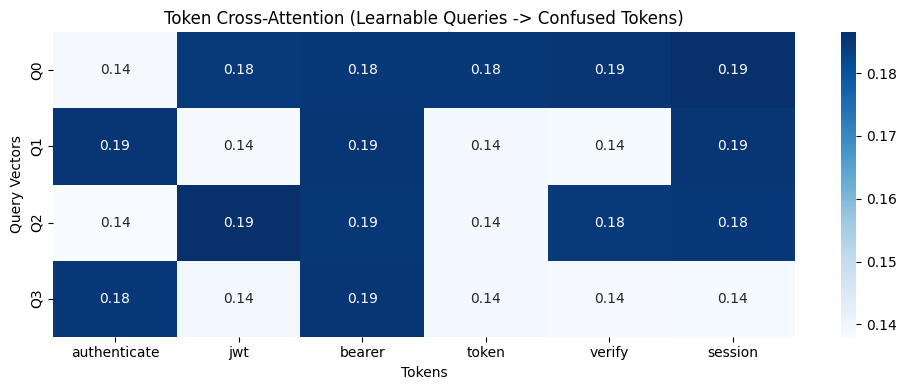

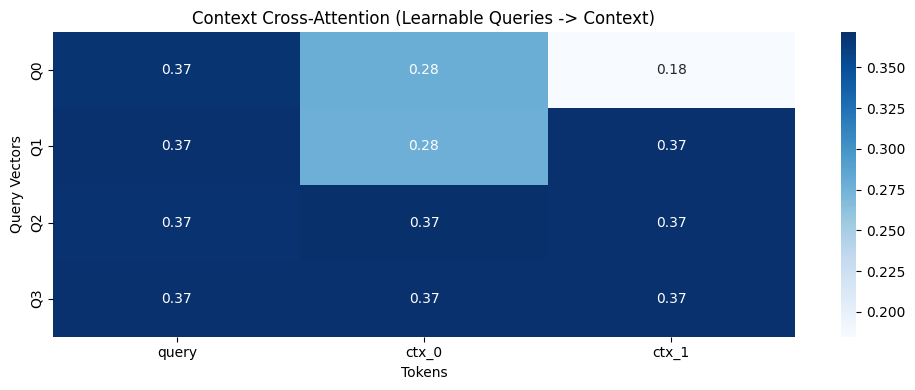

In [13]:
def visualize_attention(attention_weights, token_names, title="Cross-Attention"):
    """Visualize attention heatmap."""
    attn = attention_weights.mean(dim=0).detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(
        attn,
        xticklabels=token_names,
        yticklabels=[f'Q{i}' for i in range(attn.shape[0])],
        annot=True,
        fmt='.2f',
        cmap='Blues',
        ax=ax
    )
    ax.set_xlabel('Tokens')
    ax.set_ylabel('Query Vectors')
    ax.set_title(title)
    plt.tight_layout()
    return fig

# Visualize token attention
fig = visualize_attention(
    attention_weights['token_attention'],
    confused_tokens,
    "Token Cross-Attention (Learnable Queries -> Confused Tokens)"
)
plt.show()

# Visualize context attention
context_names = ['query'] + [f'ctx_{i}' for i in range(combined_context.shape[0] - 1)]
fig = visualize_attention(
    attention_weights['context_attention'],
    context_names,
    "Context Cross-Attention (Learnable Queries -> Context)"
)
plt.show()

## 7. Full Module Demo

In [14]:
# Initialize full module
module = LearnedQueryModule(
    embed_dim=384,
    num_query_vectors=4,
    num_heads=4,
    scoring_method="bilinear",
    score_threshold=0.1,  # Low threshold for demo
    top_k=3,
).to(device)

# Set available files (simulated codebase)
available_files = [
    "src/auth/jwt_handler.py",
    "src/auth/session.py",
    "src/api/routes.py",
    "src/api/middleware.py",
    "src/models/user.py",
    "src/utils/helpers.py",
    "tests/test_auth.py",
]
module.set_available_files(available_files)

# Run inference
result = module(
    confused_tokens=["jwt", "authenticate", "bearer", "token", "verify"],
    confused_probs=[0.25, 0.20, 0.18, 0.15, 0.10],
    original_query="How does JWT authentication work?",
    generated_context="In our Flask app, authentication uses JWT tokens for",
    return_attention=True,
)

print("=" * 60)
print("LEARNED QUERY MODULE RESULT")
print("=" * 60)
print(f"\nMatched Files: {result.matched_files}")
print(f"\nFile Scores (top 5):")
for path, score in sorted(result.file_scores.items(), key=lambda x: -x[1])[:5]:
    print(f"  {path}: {score:.4f}")
print(f"\nConfidence: {result.confidence:.4f}")
print(f"Query Embedding Shape: {result.query_embedding.shape}")

LEARNED QUERY MODULE RESULT

Matched Files: ['src/models/user.py', 'src/auth/jwt_handler.py', 'src/api/middleware.py']

File Scores (top 5):
  src/models/user.py: 0.1941
  src/auth/jwt_handler.py: 0.1902
  src/api/middleware.py: 0.1505
  src/utils/helpers.py: 0.1484
  src/auth/session.py: 0.1382

Confidence: 0.0075
Query Embedding Shape: torch.Size([384])


## 8. Training Demo

Training for 10 demo epochs...

Epoch  1: loss = 2.0908
Epoch  2: loss = 0.9907
Epoch  3: loss = 0.6073
Epoch  4: loss = 0.4042
Epoch  5: loss = 0.3247
Epoch  6: loss = 0.2524
Epoch  7: loss = 0.2212
Epoch  8: loss = 0.2198
Epoch  9: loss = 0.2026
Epoch 10: loss = 0.2062


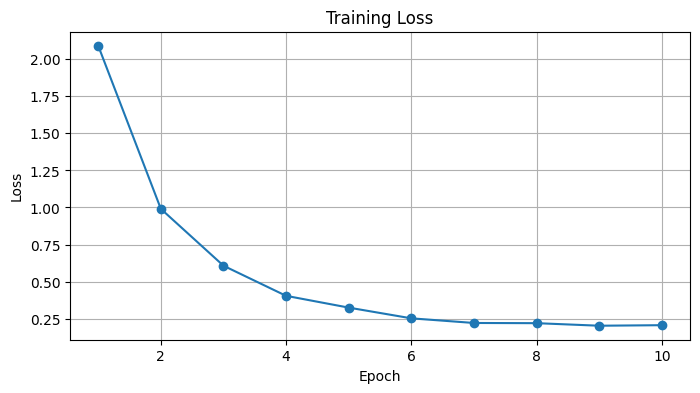

In [15]:
@dataclass
class TrainingSample:
    """Training sample for the learned query module."""
    confused_tokens: List[str]
    confused_probs: List[float]
    original_query: str
    generated_context: str
    relevant_files: List[str]
    sample_id: str = ""

# Create sample training data
training_samples = [
    TrainingSample(
        confused_tokens=["jwt", "authenticate", "bearer"],
        confused_probs=[0.3, 0.25, 0.2],
        original_query="How does authentication work?",
        generated_context="In our app, authentication uses",
        relevant_files=["src/auth/jwt_handler.py", "src/auth/session.py"],
        sample_id="sample_001",
    ),
    TrainingSample(
        confused_tokens=["route", "endpoint", "api", "handler"],
        confused_probs=[0.25, 0.22, 0.18, 0.15],
        original_query="Where are API routes defined?",
        generated_context="The API routes are defined in",
        relevant_files=["src/api/routes.py"],
        sample_id="sample_002",
    ),
    TrainingSample(
        confused_tokens=["user", "model", "schema", "database"],
        confused_probs=[0.28, 0.24, 0.20, 0.15],
        original_query="How is the User model defined?",
        generated_context="The User model has fields for",
        relevant_files=["src/models/user.py"],
        sample_id="sample_003",
    ),
]

# File to index mapping
file_to_idx = {f: i for i, f in enumerate(available_files)}

# Initialize loss function and optimizer
loss_fn = QueryPoolerLoss(ranking_weight=1.0, contrastive_weight=0.5, attention_reg_weight=0.1)
optimizer = torch.optim.AdamW(module.parameters(), lr=1e-4, weight_decay=0.01)

# Training loop
print("Training for 10 demo epochs...\n")
history = []

for epoch in range(10):
    module.train()
    epoch_loss = 0.0

    for sample in training_samples:
        optimizer.zero_grad()

        # Forward pass
        result = module(
            confused_tokens=sample.confused_tokens,
            confused_probs=sample.confused_probs,
            original_query=sample.original_query,
            generated_context=sample.generated_context,
            return_attention=True,
        )

        # Get relevant indices
        relevant_indices = [file_to_idx[f] for f in sample.relevant_files if f in file_to_idx]

        # Compute scores
        scores = module.scorer(result.query_embedding, module._file_embeddings)

        # Compute loss
        attention_weights = {
            'token_attention': result.token_attention,
            'context_attention': result.context_attention,
        }
        loss, components = loss_fn(
            result.query_embedding, module._file_embeddings, scores,
            relevant_indices, attention_weights
        )

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(module.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(training_samples)
    history.append(avg_loss)
    print(f"Epoch {epoch+1:2d}: loss = {avg_loss:.4f}")

# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history)+1), history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

## 9. Evaluate After Training

In [16]:
# Evaluate on training samples
module.eval()

print("=" * 60)
print("EVALUATION AFTER TRAINING")
print("=" * 60)

for sample in training_samples:
    with torch.no_grad():
        result = module(
            confused_tokens=sample.confused_tokens,
            confused_probs=sample.confused_probs,
            original_query=sample.original_query,
            generated_context=sample.generated_context,
        )

    print(f"\n[{sample.sample_id}] Query: {sample.original_query}")
    print(f"  Ground Truth: {sample.relevant_files}")
    print(f"  Predicted:    {result.matched_files}")
    print(f"  Confidence:   {result.confidence:.3f}")

    # Check hit
    hits = [f for f in result.matched_files if f in sample.relevant_files]
    print(f"  Hits@3:       {len(hits)}/{len(sample.relevant_files)}")

EVALUATION AFTER TRAINING

[sample_001] Query: How does authentication work?
  Ground Truth: ['src/auth/jwt_handler.py', 'src/auth/session.py']
  Predicted:    ['src/auth/jwt_handler.py', 'src/auth/session.py']
  Confidence:   0.000
  Hits@3:       2/2

[sample_002] Query: Where are API routes defined?
  Ground Truth: ['src/api/routes.py']
  Predicted:    ['src/api/routes.py', 'src/auth/jwt_handler.py', 'src/auth/session.py']
  Confidence:   0.000
  Hits@3:       1/1

[sample_003] Query: How is the User model defined?
  Ground Truth: ['src/models/user.py']
  Predicted:    ['src/models/user.py', 'src/api/middleware.py', 'src/utils/helpers.py']
  Confidence:   0.000
  Hits@3:       1/1


## 10. Load Training Data

### Training Data Format

Upload JSON files with training samples in this format:

**training_samples.json:**
```json
[
    {
        "confused_tokens": ["auth", "jwt", "token"],
        "confused_probs": [0.3, 0.25, 0.2],
        "original_query": "How does authentication work?",
        "generated_context": "In our app...",
        "relevant_files": ["auth_service.py"],
        "sample_id": "sample_001"
    }
]
```

**file_list.json:**
```json
["auth_service.py", "api_router.py", "cache_service.py", ...]
```

Run the cell below to upload your data files.

In [17]:
# Upload training data files
training_data = None
file_list = None

def upload_training_data():
    """Upload training data JSON file."""
    if IN_COLAB:
        print("Please upload your training_samples.json file:")
        uploaded = files.upload()
        if uploaded:
            filename = list(uploaded.keys())[0]
            data = json.loads(uploaded[filename].decode('utf-8'))
            print(f"Loaded {len(data)} training samples from {filename}")
            return data
    else:
        print("Running locally - please load training data manually")
        print("Example: training_data = json.load(open('training_samples.json'))")
    return None

def upload_file_list():
    """Upload file list JSON file."""
    if IN_COLAB:
        print("\nPlease upload your file_list.json:")
        uploaded = files.upload()
        if uploaded:
            filename = list(uploaded.keys())[0]
            data = json.loads(uploaded[filename].decode('utf-8'))
            print(f"Loaded {len(data)} file paths from {filename}")
            return data
    else:
        print("Running locally - please load file list manually")
        print("Example: file_list = json.load(open('file_list.json'))")
    return None

# Upload the files
training_data = upload_training_data()
file_list = upload_file_list()

# Show sample if loaded
if training_data:
    print("\n--- Sample training data ---")
    print(json.dumps(training_data[0], indent=2))

Please upload your training_samples.json file:


Saving training_samples.json to training_samples.json
Loaded 17 training samples from training_samples.json

Please upload your file_list.json:


Saving file_list.json to file_list.json
Loaded 22 file paths from file_list.json

--- Sample training data ---
{
  "confused_tokens": [
    "TokenManager",
    "generate",
    "token",
    "signature",
    "payload"
  ],
  "confused_probs": [
    0.25,
    0.22,
    0.18,
    0.15,
    0.12
  ],
  "original_query": "How does the TokenManager generate authentication tokens?",
  "generated_context": "TokenManager generates tokens by creating a",
  "relevant_files": [
    "auth_service.py"
  ],
  "sample_id": "ablation_single_hop_001",
  "spike_position": 12,
  "uncertainty_value": 3.2
}


TRAINING WITH LOADED DATA
Loaded 22 files
Using 17 valid training samples

Training for 20 epochs...
Epoch  5: loss = 0.4304
Epoch 10: loss = 0.2459
Epoch 15: loss = 0.1746
Epoch 20: loss = 0.1700


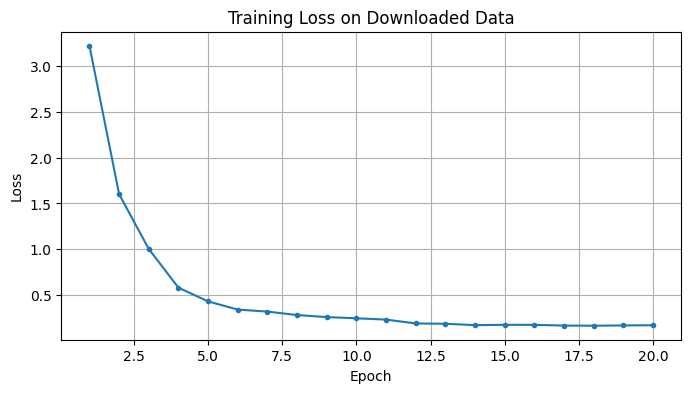


EVALUATION

[ablation_single_hop_001]
  Query: How does the TokenManager generate authentication ...
  Ground Truth: ['auth_service.py']
  Predicted: ['auth_service.py', 'api_router.py']
  Hits@3: 1/1

[ablation_single_hop_002]
  Query: What eviction strategy does the InMemoryCache use?...
  Ground Truth: ['cache_service.py']
  Predicted: ['cache_service.py', 'api_router.py']
  Hits@3: 1/1

[ablation_multi_hop_001]
  Query: How does the auth_middleware validate requests and...
  Ground Truth: ['api_router.py', 'auth_service.py']
  Predicted: ['auth_service.py', 'api_router.py']
  Hits@3: 2/2

[ablation_multi_hop_002]
  Query: If I create a TieredCache with InMemoryCache as L1...
  Ground Truth: ['cache_service.py']
  Predicted: ['cache_service.py']
  Hits@3: 1/1

[flask_001]
  Query: How does Flask handle URL routing and decorators?...
  Ground Truth: ['src/flask/app.py', 'src/flask/scaffold.py']
  Predicted: ['src/flask/app.py', 'src/flask/scaffold.py']
  Hits@3: 2/2

Accuracy (any h

In [18]:
# Train with downloaded/uploaded data
if training_data and file_list:
    print("=" * 60)
    print("TRAINING WITH LOADED DATA")
    print("=" * 60)

    # Create fresh module
    trained_module = LearnedQueryModule(
        embed_dim=384,
        num_query_vectors=4,
        num_heads=4,
        scoring_method="bilinear",
        score_threshold=0.1,
        top_k=3,
    ).to(device)

    # Set files
    trained_module.set_available_files(file_list)
    print(f"Loaded {len(file_list)} files")

    # Create file index
    file_to_idx = {f: i for i, f in enumerate(file_list)}

    # Convert to TrainingSample objects
    samples = []
    for item in training_data:
        # Filter to only files we have
        relevant = [f for f in item.get("relevant_files", []) if f in file_to_idx]
        if relevant and item.get("confused_tokens"):
            samples.append(TrainingSample(
                confused_tokens=item["confused_tokens"],
                confused_probs=item.get("confused_probs", [0.2] * len(item["confused_tokens"])),
                original_query=item.get("original_query", ""),
                generated_context=item.get("generated_context", ""),
                relevant_files=relevant,
                sample_id=item.get("sample_id", ""),
            ))
    print(f"Using {len(samples)} valid training samples")

    # Training
    loss_fn = QueryPoolerLoss(ranking_weight=1.0, contrastive_weight=0.5, attention_reg_weight=0.1)
    optimizer = torch.optim.AdamW(trained_module.parameters(), lr=1e-4, weight_decay=0.01)

    history = []
    num_epochs = 20

    print(f"\nTraining for {num_epochs} epochs...")
    for epoch in range(num_epochs):
        trained_module.train()
        epoch_loss = 0.0

        for sample in samples:
            optimizer.zero_grad()

            result = trained_module(
                confused_tokens=sample.confused_tokens,
                confused_probs=sample.confused_probs,
                original_query=sample.original_query,
                generated_context=sample.generated_context,
                return_attention=True,
            )

            relevant_indices = [file_to_idx[f] for f in sample.relevant_files]
            scores = trained_module.scorer(result.query_embedding, trained_module._file_embeddings)

            attention_weights = {'token_attention': result.token_attention, 'context_attention': result.context_attention}
            loss, _ = loss_fn(result.query_embedding, trained_module._file_embeddings, scores, relevant_indices, attention_weights)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(trained_module.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(samples)
        history.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:2d}: loss = {avg_loss:.4f}")

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(history)+1), history, marker='o', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss on Downloaded Data')
    plt.grid(True)
    plt.show()

    # Evaluate
    print("\n" + "=" * 60)
    print("EVALUATION")
    print("=" * 60)
    trained_module.eval()

    correct = 0
    total = 0
    for sample in samples[:5]:  # Show first 5
        with torch.no_grad():
            result = trained_module(
                confused_tokens=sample.confused_tokens,
                confused_probs=sample.confused_probs,
                original_query=sample.original_query,
                generated_context=sample.generated_context,
            )

        hits = [f for f in result.matched_files if f in sample.relevant_files]
        print(f"\n[{sample.sample_id}]")
        print(f"  Query: {sample.original_query[:50]}...")
        print(f"  Ground Truth: {sample.relevant_files}")
        print(f"  Predicted: {result.matched_files}")
        print(f"  Hits@3: {len(hits)}/{len(sample.relevant_files)}")

        if hits:
            correct += 1
        total += 1

    print(f"\nAccuracy (any hit): {correct}/{total} = {correct/total:.1%}")
else:
    print("No training data loaded. Run Option A or B above first.")

## 11. Comprehensive Evaluation & Baseline Comparison

This section computes standard retrieval metrics and compares against baseline methods:
- **Learned Query Pooler**: Our cross-attention approach
- **Heuristic Baseline**: Simple keyword matching (simulates TopicInferrer)
- **Random Baseline**: Random file selection
- **BM25 Baseline**: Classic text retrieval

In [19]:
# ============================================================================
# RETRIEVAL METRICS
# ============================================================================

def precision_at_k(predicted: List[str], relevant: List[str], k: int) -> float:
    """Precision@K: fraction of top-k predictions that are relevant."""
    if k == 0:
        return 0.0
    predicted_k = predicted[:k]
    hits = len(set(predicted_k) & set(relevant))
    return hits / k

def recall_at_k(predicted: List[str], relevant: List[str], k: int) -> float:
    """Recall@K: fraction of relevant items found in top-k."""
    if not relevant:
        return 0.0
    predicted_k = predicted[:k]
    hits = len(set(predicted_k) & set(relevant))
    return hits / len(relevant)

def average_precision(predicted: List[str], relevant: List[str]) -> float:
    """Average Precision: area under precision-recall curve."""
    if not relevant:
        return 0.0
    relevant_set = set(relevant)
    hits = 0
    sum_precision = 0.0
    for i, pred in enumerate(predicted):
        if pred in relevant_set:
            hits += 1
            sum_precision += hits / (i + 1)
    return sum_precision / len(relevant) if relevant else 0.0

def ndcg_at_k(predicted: List[str], relevant: List[str], k: int) -> float:
    """Normalized Discounted Cumulative Gain at K."""
    if not relevant or k == 0:
        return 0.0

    relevant_set = set(relevant)

    # DCG
    dcg = 0.0
    for i, pred in enumerate(predicted[:k]):
        if pred in relevant_set:
            dcg += 1.0 / np.log2(i + 2)  # i+2 because log2(1) = 0

    # Ideal DCG
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))

    return dcg / idcg if idcg > 0 else 0.0

def mrr(predicted: List[str], relevant: List[str]) -> float:
    """Mean Reciprocal Rank: 1/rank of first relevant item."""
    relevant_set = set(relevant)
    for i, pred in enumerate(predicted):
        if pred in relevant_set:
            return 1.0 / (i + 1)
    return 0.0

def compute_all_metrics(predicted: List[str], relevant: List[str], k: int = 3) -> Dict[str, float]:
    """Compute all retrieval metrics."""
    return {
        f'P@{k}': precision_at_k(predicted, relevant, k),
        f'R@{k}': recall_at_k(predicted, relevant, k),
        f'NDCG@{k}': ndcg_at_k(predicted, relevant, k),
        'MRR': mrr(predicted, relevant),
        'MAP': average_precision(predicted, relevant),
    }

print("Retrieval metrics defined")

Retrieval metrics defined


In [20]:
# ============================================================================
# BASELINE METHODS
# ============================================================================

class HeuristicBaseline:
    """
    Simulates the heuristic TopicInferrer approach.
    Uses keyword matching between confused tokens and file paths.
    """
    def __init__(self, file_paths: List[str]):
        self.file_paths = file_paths
        self._file_keywords = {}
        for path in file_paths:
            # Extract keywords from file path
            parts = re.split(r'[/\\._]', path.lower())
            keywords = set(p for p in parts if len(p) >= 2)
            self._file_keywords[path] = keywords

    def predict(self, confused_tokens: List[str], query: str = "", k: int = 3) -> List[str]:
        """Score files by keyword overlap with confused tokens."""
        query_keywords = set(t.lower() for t in confused_tokens)
        # Also add keywords from query
        query_words = set(w.lower() for w in re.findall(r'\w+', query) if len(w) >= 3)
        query_keywords.update(query_words)

        scores = {}
        for path, file_kw in self._file_keywords.items():
            overlap = len(query_keywords & file_kw)
            # Bonus for exact matches
            exact_bonus = sum(1 for t in confused_tokens if t.lower() in path.lower())
            scores[path] = overlap + exact_bonus * 0.5

        sorted_files = sorted(scores.items(), key=lambda x: -x[1])
        return [f for f, s in sorted_files[:k]]


class RandomBaseline:
    """Random file selection baseline."""
    def __init__(self, file_paths: List[str]):
        self.file_paths = file_paths

    def predict(self, confused_tokens: List[str], query: str = "", k: int = 3) -> List[str]:
        """Return k random files."""
        import random
        return random.sample(self.file_paths, min(k, len(self.file_paths)))


class BM25Baseline:
    """BM25 text retrieval baseline."""
    def __init__(self, file_paths: List[str], k1: float = 1.5, b: float = 0.75):
        self.file_paths = file_paths
        self.k1 = k1
        self.b = b

        # Build document representations from file paths
        self.docs = []
        for path in file_paths:
            parts = re.split(r'[/\\._]', path.lower())
            tokens = [p for p in parts if len(p) >= 2]
            self.docs.append(tokens)

        # Compute IDF
        self.avgdl = np.mean([len(d) for d in self.docs])
        self.doc_freqs = {}
        for doc in self.docs:
            for term in set(doc):
                self.doc_freqs[term] = self.doc_freqs.get(term, 0) + 1

        self.N = len(self.docs)

    def _bm25_score(self, query_terms: List[str], doc_idx: int) -> float:
        doc = self.docs[doc_idx]
        doc_len = len(doc)
        score = 0.0

        term_freqs = {}
        for term in doc:
            term_freqs[term] = term_freqs.get(term, 0) + 1

        for term in query_terms:
            if term not in term_freqs:
                continue

            tf = term_freqs[term]
            df = self.doc_freqs.get(term, 0)
            idf = np.log((self.N - df + 0.5) / (df + 0.5) + 1)

            numerator = tf * (self.k1 + 1)
            denominator = tf + self.k1 * (1 - self.b + self.b * doc_len / self.avgdl)
            score += idf * numerator / denominator

        return score

    def predict(self, confused_tokens: List[str], query: str = "", k: int = 3) -> List[str]:
        """Score files using BM25."""
        query_terms = [t.lower() for t in confused_tokens]
        query_terms.extend(w.lower() for w in re.findall(r'\w+', query) if len(w) >= 3)

        scores = [(self.file_paths[i], self._bm25_score(query_terms, i))
                  for i in range(len(self.file_paths))]
        scores.sort(key=lambda x: -x[1])

        return [f for f, s in scores[:k]]


class CosineBaseline:
    """Cosine similarity baseline using sentence embeddings."""
    def __init__(self, file_paths: List[str], model_name: str = 'all-MiniLM-L6-v2'):
        self.file_paths = file_paths
        self._encoder = SentenceTransformer(model_name)

        # Encode file paths
        texts = [' '.join(re.split(r'[/\\._]', p)) for p in file_paths]
        self._file_embeddings = self._encoder.encode(texts, show_progress_bar=False)

    def predict(self, confused_tokens: List[str], query: str = "", k: int = 3) -> List[str]:
        """Score files by cosine similarity."""
        query_text = ' '.join(confused_tokens) + ' ' + query
        query_emb = self._encoder.encode([query_text], show_progress_bar=False)[0]

        # Compute cosine similarities
        similarities = np.dot(self._file_embeddings, query_emb) / (
            np.linalg.norm(self._file_embeddings, axis=1) * np.linalg.norm(query_emb) + 1e-8
        )

        indices = np.argsort(-similarities)[:k]
        return [self.file_paths[i] for i in indices]

print("Baseline methods defined: Heuristic, Random, BM25, Cosine")

Baseline methods defined: Heuristic, Random, BM25, Cosine


In [21]:
# ============================================================================
# RUN EVALUATION ON ALL METHODS
# ============================================================================

def evaluate_all_methods(eval_samples, file_list, trained_module, k=3):
    """Evaluate all methods on the given samples."""

    # Initialize baselines
    heuristic = HeuristicBaseline(file_list)
    random_baseline = RandomBaseline(file_list)
    bm25 = BM25Baseline(file_list)
    cosine = CosineBaseline(file_list)

    # Results storage
    results = {
        'Learned Query Pooler': [],
        'Heuristic (TopicInferrer)': [],
        'BM25': [],
        'Cosine Similarity': [],
        'Random': [],
    }

    trained_module.eval()

    for sample in eval_samples:
        relevant = sample.relevant_files
        tokens = sample.confused_tokens
        query = sample.original_query

        # Learned Query Pooler
        with torch.no_grad():
            result = trained_module(
                confused_tokens=tokens,
                confused_probs=sample.confused_probs,
                original_query=query,
                generated_context=sample.generated_context,
            )
        learned_pred = [f for f, s in sorted(result.file_scores.items(), key=lambda x: -x[1])[:k]]

        # Baselines
        heuristic_pred = heuristic.predict(tokens, query, k)
        bm25_pred = bm25.predict(tokens, query, k)
        cosine_pred = cosine.predict(tokens, query, k)
        random_pred = random_baseline.predict(tokens, query, k)

        # Compute metrics
        results['Learned Query Pooler'].append(compute_all_metrics(learned_pred, relevant, k))
        results['Heuristic (TopicInferrer)'].append(compute_all_metrics(heuristic_pred, relevant, k))
        results['BM25'].append(compute_all_metrics(bm25_pred, relevant, k))
        results['Cosine Similarity'].append(compute_all_metrics(cosine_pred, relevant, k))
        results['Random'].append(compute_all_metrics(random_pred, relevant, k))

    # Aggregate results
    aggregated = {}
    for method, sample_results in results.items():
        aggregated[method] = {}
        for metric in sample_results[0].keys():
            values = [r[metric] for r in sample_results]
            aggregated[method][metric] = {
                'mean': np.mean(values),
                'std': np.std(values),
            }

    return aggregated, results

# Run evaluation if we have training data
if training_data and file_list and 'trained_module' in dir():
    print("=" * 70)
    print("COMPREHENSIVE EVALUATION: Learned Query Pooler vs Baselines")
    print("=" * 70)

    # Use the samples we created during training
    eval_results, detailed_results = evaluate_all_methods(samples, file_list, trained_module, k=3)

    # Create results DataFrame
    rows = []
    for method, metrics in eval_results.items():
        row = {'Method': method}
        for metric, stats in metrics.items():
            row[metric] = f"{stats['mean']:.3f} ± {stats['std']:.3f}"
        rows.append(row)

    results_df = pd.DataFrame(rows)
    results_df = results_df.set_index('Method')

    print(f"\nEvaluation on {len(samples)} samples (k=3):\n")
    print(results_df.to_string())

    # Also show mean values for easy comparison
    print("\n" + "-" * 70)
    print("Mean Values Only:")
    print("-" * 70)

    mean_rows = []
    for method, metrics in eval_results.items():
        row = {'Method': method}
        for metric, stats in metrics.items():
            row[metric] = stats['mean']
        mean_rows.append(row)

    mean_df = pd.DataFrame(mean_rows).set_index('Method')
    print(mean_df.round(3).to_string())
else:
    print("Please run training first (Section 10) to evaluate.")

COMPREHENSIVE EVALUATION: Learned Query Pooler vs Baselines

Evaluation on 17 samples (k=3):

                                     P@3            R@3         NDCG@3            MRR            MAP
Method                                                                                              
Learned Query Pooler       0.588 ± 0.215  1.000 ± 0.000  1.000 ± 0.000  1.000 ± 0.000  1.000 ± 0.000
Heuristic (TopicInferrer)  0.471 ± 0.200  0.843 ± 0.277  0.784 ± 0.265  0.824 ± 0.294  0.727 ± 0.298
BM25                       0.471 ± 0.200  0.843 ± 0.277  0.788 ± 0.263  0.824 ± 0.294  0.732 ± 0.295
Cosine Similarity          0.471 ± 0.200  0.833 ± 0.229  0.828 ± 0.213  0.931 ± 0.190  0.775 ± 0.268
Random                     0.059 ± 0.127  0.147 ± 0.333  0.110 ± 0.238  0.118 ± 0.273  0.088 ± 0.191

----------------------------------------------------------------------
Mean Values Only:
----------------------------------------------------------------------
                             P@3    R@

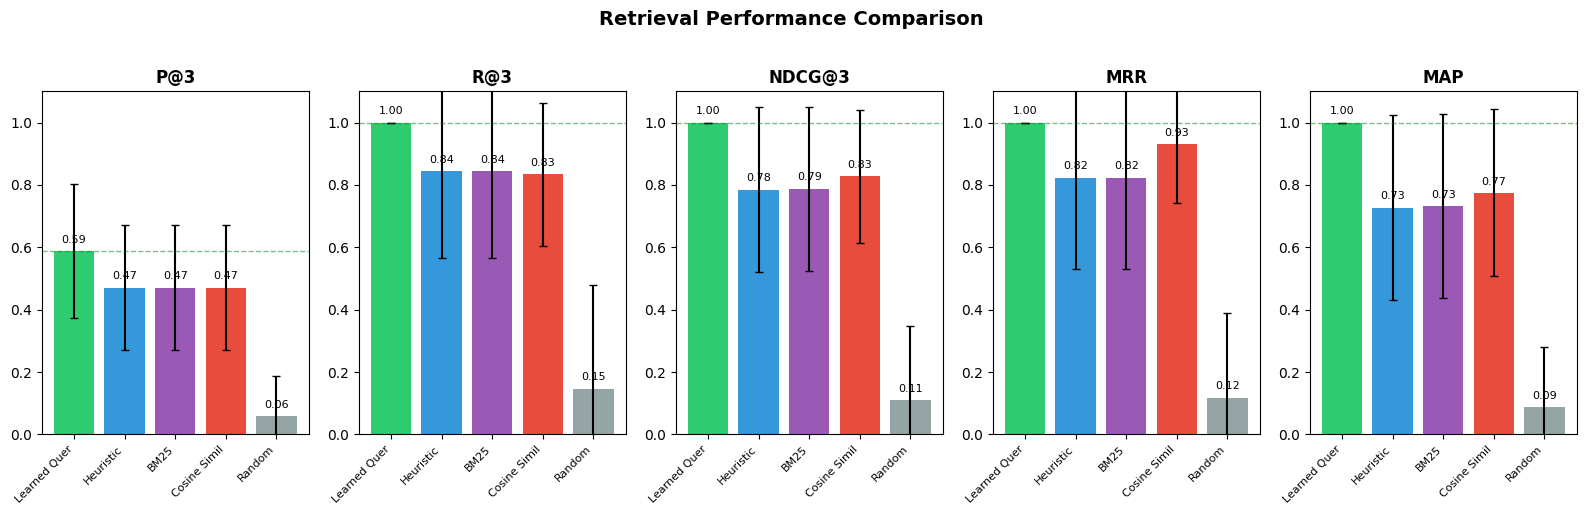


IMPROVEMENT ANALYSIS: Learned Query Pooler vs Heuristic Baseline

Metric           | Learned | Heuristic | Δ Improvement
-------------------------------------------------------
P@3              |   0.588 |     0.471 | ↑ 0.118 (+25.0%)
R@3              |   1.000 |     0.843 | ↑ 0.157 (+18.6%)
NDCG@3           |   1.000 |     0.784 | ↑ 0.216 (+27.5%)
MRR              |   1.000 |     0.824 | ↑ 0.176 (+21.4%)
MAP              |   1.000 |     0.727 | ↑ 0.273 (+37.5%)
-------------------------------------------------------
Composite        |   0.918 |     0.730 | ↑ 0.188 (+25.7%)


In [22]:
# ============================================================================
# VISUALIZATION: BAR CHART COMPARISON
# ============================================================================

if 'eval_results' in dir():
    # Prepare data for plotting
    methods = list(eval_results.keys())
    metrics = ['P@3', 'R@3', 'NDCG@3', 'MRR', 'MAP']

    # Create bar chart
    fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5))

    colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#95a5a6']

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        values = [eval_results[m][metric]['mean'] for m in methods]
        errors = [eval_results[m][metric]['std'] for m in methods]

        bars = ax.bar(range(len(methods)), values, yerr=errors, capsize=3, color=colors)
        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.set_xticks(range(len(methods)))
        ax.set_xticklabels([m.split('(')[0].strip()[:12] for m in methods], rotation=45, ha='right', fontsize=8)
        ax.axhline(y=values[0], color='green', linestyle='--', alpha=0.5, linewidth=1)

        # Add value labels on bars
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=8)

    plt.suptitle('Retrieval Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ============================================================================
    # IMPROVEMENT ANALYSIS
    # ============================================================================
    print("\n" + "=" * 70)
    print("IMPROVEMENT ANALYSIS: Learned Query Pooler vs Heuristic Baseline")
    print("=" * 70)

    learned = eval_results['Learned Query Pooler']
    heuristic = eval_results['Heuristic (TopicInferrer)']

    print("\nMetric           | Learned | Heuristic | Δ Improvement")
    print("-" * 55)
    for metric in metrics:
        l_val = learned[metric]['mean']
        h_val = heuristic[metric]['mean']
        diff = l_val - h_val
        pct = (diff / h_val * 100) if h_val > 0 else 0
        symbol = "↑" if diff > 0 else "↓" if diff < 0 else "="
        print(f"{metric:16} | {l_val:7.3f} | {h_val:9.3f} | {symbol} {abs(diff):.3f} ({pct:+.1f}%)")

    # Composite score (average of all metrics)
    learned_composite = np.mean([learned[m]['mean'] for m in metrics])
    heuristic_composite = np.mean([heuristic[m]['mean'] for m in metrics])

    print("-" * 55)
    print(f"{'Composite':16} | {learned_composite:7.3f} | {heuristic_composite:9.3f} | ", end="")
    diff = learned_composite - heuristic_composite
    symbol = "↑" if diff > 0 else "↓"
    print(f"{symbol} {abs(diff):.3f} ({diff/heuristic_composite*100:+.1f}%)")
else:
    print("Run the evaluation cell above first.")

PER-SAMPLE ANALYSIS

Sample-by-sample comparison (Learned vs Heuristic):

[ablation_single_hop_] Learned MRR: 1.00 | Heuristic MRR: 1.00 | = TIE
[ablation_single_hop_] Learned MRR: 1.00 | Heuristic MRR: 0.50 | ✓ WIN
[ablation_multi_hop_0] Learned MRR: 1.00 | Heuristic MRR: 0.00 | ✓ WIN
[ablation_multi_hop_0] Learned MRR: 1.00 | Heuristic MRR: 1.00 | = TIE
[flask_001           ] Learned MRR: 1.00 | Heuristic MRR: 1.00 | = TIE
[flask_002           ] Learned MRR: 1.00 | Heuristic MRR: 1.00 | = TIE
[flask_003           ] Learned MRR: 1.00 | Heuristic MRR: 1.00 | = TIE
[flask_004           ] Learned MRR: 1.00 | Heuristic MRR: 1.00 | = TIE
[flask_005           ] Learned MRR: 1.00 | Heuristic MRR: 1.00 | = TIE
[fastapi_002         ] Learned MRR: 1.00 | Heuristic MRR: 0.50 | ✓ WIN

--- Summary (17 samples) ---
Wins:     3 (17.6%)
Ties:     7 (41.2%)
Losses:   0 (0.0%)


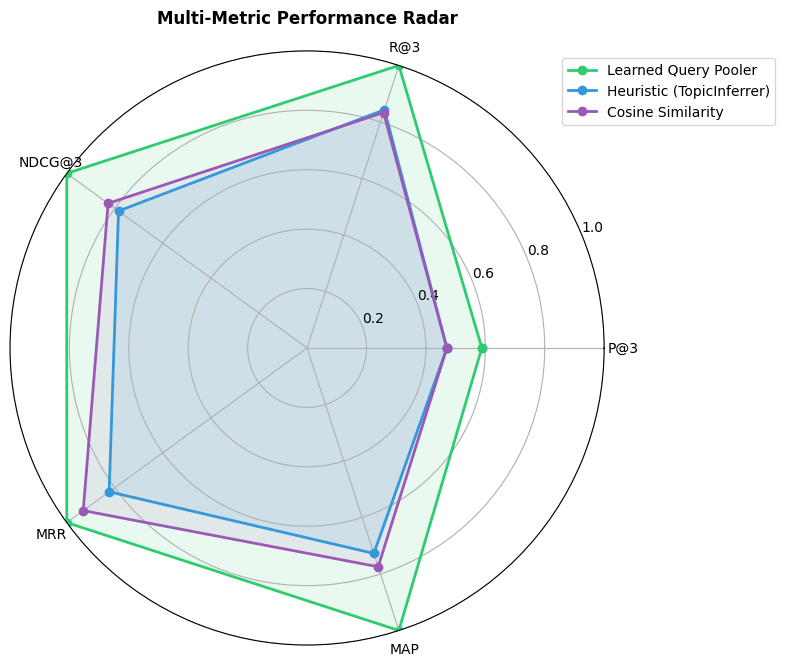

In [23]:
# ============================================================================
# PER-SAMPLE ANALYSIS: Where does Learned Query Pooler win/lose?
# ============================================================================

if 'detailed_results' in dir():
    print("=" * 70)
    print("PER-SAMPLE ANALYSIS")
    print("=" * 70)

    wins = 0
    losses = 0
    ties = 0

    print("\nSample-by-sample comparison (Learned vs Heuristic):\n")

    for i, sample in enumerate(samples[:10]):  # Show first 10
        learned_mrr = detailed_results['Learned Query Pooler'][i]['MRR']
        heuristic_mrr = detailed_results['Heuristic (TopicInferrer)'][i]['MRR']

        if learned_mrr > heuristic_mrr:
            status = "✓ WIN"
            wins += 1
        elif learned_mrr < heuristic_mrr:
            status = "✗ LOSS"
            losses += 1
        else:
            status = "= TIE"
            ties += 1

        print(f"[{sample.sample_id[:20]:20}] Learned MRR: {learned_mrr:.2f} | Heuristic MRR: {heuristic_mrr:.2f} | {status}")

    total = len(samples)
    print(f"\n--- Summary ({total} samples) ---")
    print(f"Wins:   {wins:3d} ({wins/total*100:.1f}%)")
    print(f"Ties:   {ties:3d} ({ties/total*100:.1f}%)")
    print(f"Losses: {losses:3d} ({losses/total*100:.1f}%)")

    # Radar chart for multi-metric comparison
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    categories = ['P@3', 'R@3', 'NDCG@3', 'MRR', 'MAP']
    N = len(categories)

    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the polygon

    # Plot each method
    method_colors = {
        'Learned Query Pooler': '#2ecc71',
        'Heuristic (TopicInferrer)': '#3498db',
        'Cosine Similarity': '#9b59b6',
    }

    for method, color in method_colors.items():
        values = [eval_results[method][m]['mean'] for m in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=method, color=color)
        ax.fill(angles, values, alpha=0.1, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.set_title('Multi-Metric Performance Radar', fontsize=12, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()
else:
    print("Run the evaluation cells above first.")

## 12. Save/Load Model Weights

In [24]:
# Save model weights
def save_model(module, filename="learned_query_pooler.pt"):
    torch.save(module.state_dict(), filename)
    print(f"Model saved to {filename}")
    if IN_COLAB:
        files.download(filename)

# Uncomment to save:
save_model(module)

Model saved to learned_query_pooler.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Summary & Next Steps

### What We Built

1. **ConfusedTokenEncoder**: Encodes CCE tokens with probability weighting
2. **ContextEncoder**: Encodes query + generation context
3. **LearnedQueryPooler**: Cross-attention with 4 learnable query vectors
4. **LearnedFileScorer**: Learned bilinear scoring for file matching
5. **QueryPoolerLoss**: Ranking + contrastive + attention regularization

### Evaluation Metrics

The comprehensive evaluation in Section 11 compares against:
- **Heuristic (TopicInferrer)**: Keyword matching baseline
- **BM25**: Classic text retrieval
- **Cosine Similarity**: Embedding-based retrieval
- **Random**: Lower bound baseline

### Key Metrics Tracked

| Metric | Description |
|--------|-------------|
| P@K | Precision at K - fraction of top-K that are relevant |
| R@K | Recall at K - fraction of relevant found in top-K |
| NDCG@K | Normalized Discounted Cumulative Gain |
| MRR | Mean Reciprocal Rank - 1/rank of first hit |
| MAP | Mean Average Precision |

### Success Criteria

| Metric | Heuristic Baseline | Target |
|--------|-------------------|--------|
| Composite Score | 0.611 | > 0.65 |
| Precision@3 | ~0.45 | > 0.55 |
| NDCG@3 | ~0.50 | > 0.60 |

### Next Steps

1. **More Training Data**: Collect samples from Week 9 httpx experiments
2. **Hyperparameter Search**: Tune num_query_vectors (2-8), num_heads (2-8)
3. **Cross-Validation**: Evaluate on held-out test set
4. **Integration**: Deploy as drop-in replacement for TopicInferrer

## 12. Summary & Next Steps

### What We Built

1. **ConfusedTokenEncoder**: Encodes CCE tokens with probability weighting
2. **ContextEncoder**: Encodes query + generation context
3. **LearnedQueryPooler**: Cross-attention with 4 learnable query vectors
4. **LearnedFileScorer**: Learned bilinear scoring for file matching
5. **QueryPoolerLoss**: Ranking + contrastive + attention regularization

### Success Criteria

| Metric | Current Heuristic | Target |
|--------|-------------------|--------|
| Composite Score | 0.611 | > 0.65 |
| Precision@3 | ~0.45 | > 0.55 |
| NDCG@3 | ~0.50 | > 0.60 |
| Inference Latency | N/A | < 10ms |

### Next Steps

1. **Collect Training Data**: Extract samples from Week 9 httpx benchmark
2. **Train on Real Data**: Use actual CCE spike data
3. **Hyperparameter Tuning**: Search over num_query_vectors, num_heads
4. **Benchmark**: Compare against heuristic baseline